# Autograd Engine Implementation
### Done with Numpy

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

***

## Tensor Class
Implemented:
- Backward Propagation
- Computation Graph
- Tensor Operations

In [2]:
class Tensor:
    def __init__(self, data, _children=(), _op=""):
        self.data = np.array(data, dtype=float)
        self.grad = np.zeros_like(self.data)
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += unbroadcast(out.grad, self.data.shape)
            other.grad += unbroadcast(out.grad, other.data.shape)
        out._backward = _backward
        return out
        
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += unbroadcast(self.data * out.grad, other.data.shape)
        out._backward = _backward
        return out
        
    def __neg__(self):
        return self * -1
        
    def __sub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return self + (-other)
        
    def __rsub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other) 
        return other + (-self)
        
    def __pow__(self, power):
        out = Tensor(self.data ** power, (self,), f"**{power}")
        def _backward():
            self.grad += power * (self.data ** (power - 1)) * out.grad
        out._backward = _backward
        return out

    def __matmul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data @ other.data, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return self * (other ** -1)
        
    def __rtruediv__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return other * (self**-1)
        
    def exp(self):
        out = Tensor(np.exp(self.data), (self,), "exp")
        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward
        return out
        
    def log(self):
        out = Tensor(np.log(self.data), (self,), "log")
        def _backward():
            self.grad += (1/self.data)*out.grad
        out._backward = _backward
        return out
        
    def relu(self):
        out = Tensor(np.maximum(0, self.data), (self,), "ReLU")
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def sum(self, axis=None, keepdims=False):
        out = Tensor(np.sum(self.data, axis=axis, keepdims=keepdims), (self,), "sum")
        def _backward():
            grad = out.grad
            if axis is not None and not keepdims:
                grad = np.expand_dims(grad, axis)
            self.grad += np.broadcast_to(grad, self.data.shape)
        out._backward = _backward
        return out

    def mean(self):
        return self.sum()/self.data.size

    def sigmoid(self):
        s = 1/(1 + np.exp(-self.data))
        out = Tensor(s, (self,), "sigmoid")
        def _backward():
            self.grad += s*(1-s)*out.grad
        out._backward = _backward
        return out

    def softmax(self):
        exps = self.exp()
        return exps / exps.sum(axis=1, keepdims=True)

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = np.ones_like(self.data)
        for node in reversed(topo):
            node._backward()
    def __repr__(self):
        return f"Tensor(data={self.data}, grad={self.grad})"

    @property
    def shape(self):
        return self.data.shape

def unbroadcast(grad, shape):
    while len(grad.shape) > len(shape):
        grad = grad.sum(axis=0)

    for i, dim in enumerate(shape):
        if dim == 1:
            grad = grad.sum(axis=i, keepdims=True)
    return grad

Tensor.__radd__ = Tensor.__add__
Tensor.__rmul__ = Tensor.__mul__

## Data Preparation

In [3]:
data = load_digits()
X = data.data
y = data.target

num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_np = X_train
y_train_np = y_train

## Weights Prepared and Initialized

In [4]:
lr = 0.01
epochs = 6000

m= X_train.data.shape[0]
input_size= X_train.data.shape[1]
hidden_size = 64
output_size = num_classes

np.random.seed(42)
W1 = Tensor(np.random.randn(input_size, hidden_size) * 0.01)
b1 = Tensor(np.zeros((1, hidden_size)))

W2 = Tensor(np.random.randn(hidden_size, output_size) * 0.01)
b2 = Tensor(np.zeros((1, output_size)))

losses = []

## Training Loop

In [5]:
for epoch in range(epochs):
    Xb = Tensor(X_train_np)
    yb = Tensor(y_train_np)
    
    Z1 = Xb @ W1 + b1
    A1 = Z1.relu()

    Z2 = A1 @ W2 + b2
    A2 = Z2.softmax()

    epsilon = Tensor(1e-15)
    loss = -(yb * (A2 + epsilon).log()).sum() / X_train.data.shape[0]
    losses.append(loss.data.item())

    loss.backward()
    for p in [W1, b1, W2, b2]:
        p.data -= lr*p.grad
        p.grad = np.zeros_like(p.data)
        
    if epoch % 300 == 0:
        print(f"Epoch: {epoch}. Loss: {loss.data:.4f}")

Epoch: 0. Loss: 2.3021
Epoch: 300. Loss: 2.2494
Epoch: 600. Loss: 1.8126
Epoch: 900. Loss: 1.0119
Epoch: 1200. Loss: 0.6112
Epoch: 1500. Loss: 0.4257
Epoch: 1800. Loss: 0.3077
Epoch: 2100. Loss: 0.2321
Epoch: 2400. Loss: 0.1859
Epoch: 2700. Loss: 0.1558
Epoch: 3000. Loss: 0.1345
Epoch: 3300. Loss: 0.1185
Epoch: 3600. Loss: 0.1061
Epoch: 3900. Loss: 0.0961
Epoch: 4200. Loss: 0.0877
Epoch: 4500. Loss: 0.0806
Epoch: 4800. Loss: 0.0745
Epoch: 5100. Loss: 0.0692
Epoch: 5400. Loss: 0.0645
Epoch: 5700. Loss: 0.0603


---

## Evaluation

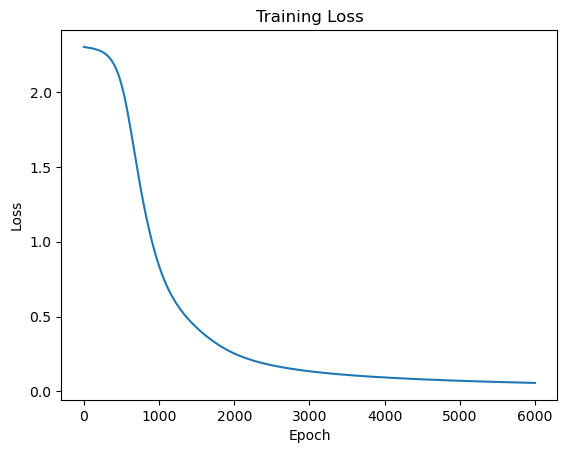

In [6]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


In [7]:
Z1_test = X_test @ W1.data + b1.data
A1_test = np.maximum(0, Z1_test)

Z2_test = A1_test @ W2.data + b2.data

# softmax
Z2_test = Z2_test - np.max(Z2_test, axis=1, keepdims=True)
exp_z = np.exp(Z2_test)
A2_test = exp_z / np.sum(exp_z, axis=1, keepdims=True)

y_pred = np.argmax(A2_test, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

Accuracy: 0.9694444444444444
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 32  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  1  0  0 28  0]
 [ 0  0  0  0  0  0  0  0  2 38]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.97      1.00      0.98        28
           2       0.97      1.00      0.99        33
           3       1.00      0.94      0.97        34
           4       1.00      1.00      1.00        46
           5       0.96      0.94      0.95        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.93      0.93      0.93        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97 